In [1]:
%load_ext autoreload
%autoreload 2

In [1]:
from few.trajectory.inspiral import EMRIInspiral
from few.trajectory.ode.IPAT1R import Trajectory1PAT1R
import matplotlib.pyplot as plt
import numpy as np

# ODE

In [2]:
ode = Trajectory1PAT1R()

Output()

In [3]:
m1 = 1e6       # primary mass [solar masses]
m2 = 1e6       # secondary mass [solar masses]

a  = -0.2       # primary spin chi1 (dimensionless)
chit2  = -0.1   # secondary spin
deltaM = 0.0

In [4]:
ode.add_fixed_parameters(m1, m2, a, [chit2])
r_values = np.linspace(6.0, 15.0, 1000)
rdot_values = [ode.evaluate_rhs([r, 0.0, 1.0, 0.0, 0.0, 0.0, deltaM, chit2])[0] for r in r_values]
chit1dot_values = [ode.evaluate_rhs([r, 0.0, 1.0, 0.0, 0.0, 0.0, deltaM, chit2])[-1] for r in r_values]
deltaMdot_values = [ode.evaluate_rhs([r, 0.0, 1.0, 0.0, 0.0, 0.0, deltaM, chit2])[-2] for r in r_values]

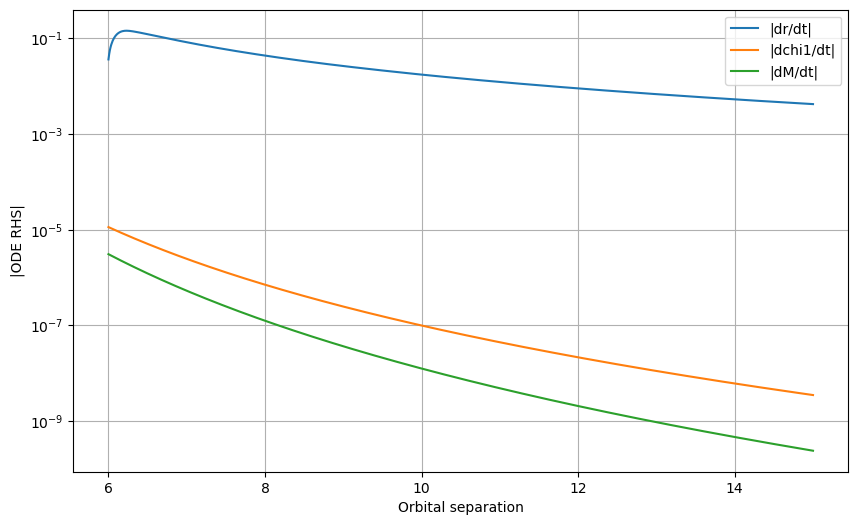

In [5]:
plt.figure(figsize=(10, 6))
plt.plot(r_values, np.abs(rdot_values), label="|dr/dt|")
plt.plot(r_values, np.abs(chit1dot_values), label="|dchi1/dt|")
plt.plot(r_values, np.abs(deltaMdot_values), label="|dM/dt|")
plt.legend()
plt.xlabel("Orbital separation")
plt.ylabel("|ODE RHS|")
plt.yscale("log")
plt.grid()
plt.show()

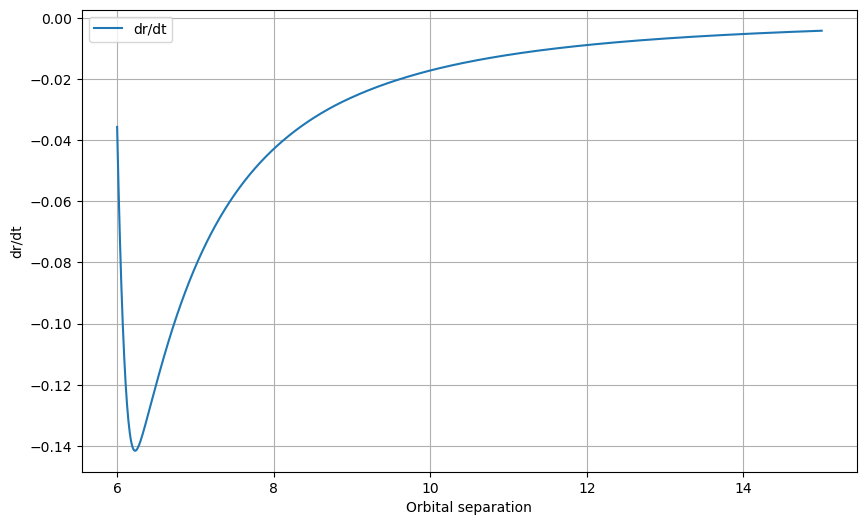

In [6]:
plt.figure(figsize=(10, 6))
plt.plot(r_values, rdot_values, label="dr/dt")
plt.legend()
plt.xlabel("Orbital separation")
plt.ylabel("dr/dt")
plt.grid()
plt.show()

# Trajectory

In [7]:
traj = EMRIInspiral(func=Trajectory1PAT1R)

In [8]:
m1 = 1e6       # primary mass [solar masses]
m2 = 1e6       # secondary mass [solar masses]

a  = -0.2       # primary spin chi1 (dimensionless)
chi2  = -0.1   # secondary spin
p0 = 15.0      # initial orbital separation [M]

dt = 1.   # time step [s]
T  = 1    # total duration [yr]

In [9]:
t, p, e, x, Phi_phi, Phi_theta, Phi_r, deltaM, deltachit1 = traj(
    m1, m2,
    a,        # chi1 (primary spin)
    p0,
    0.0,      # e0: circular
    1.0,      # xI: equatorial prograde
    chi2,
    T=T,
    dt=dt,
    in_coordinate_time=False
)

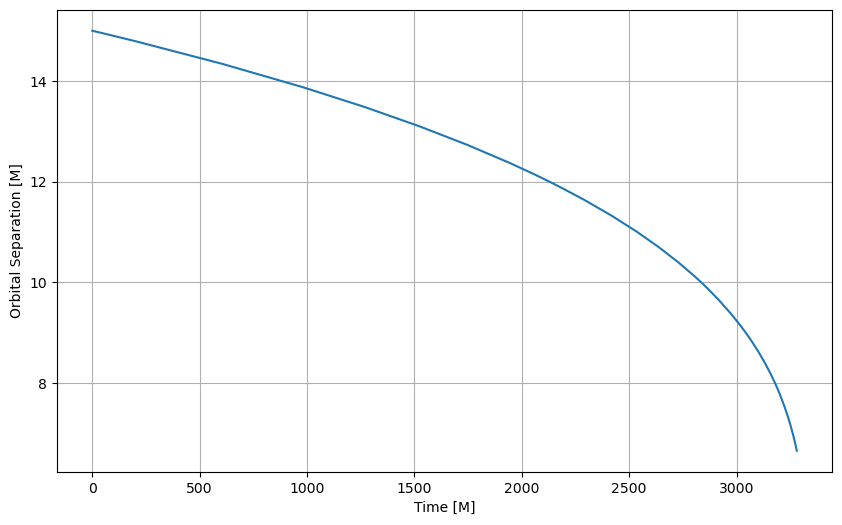

In [10]:
plt.figure(figsize=(10, 6))
plt.plot(t, p)
plt.xlabel("Time [M]")
plt.ylabel("Orbital Separation [M]")
plt.grid()
plt.show()

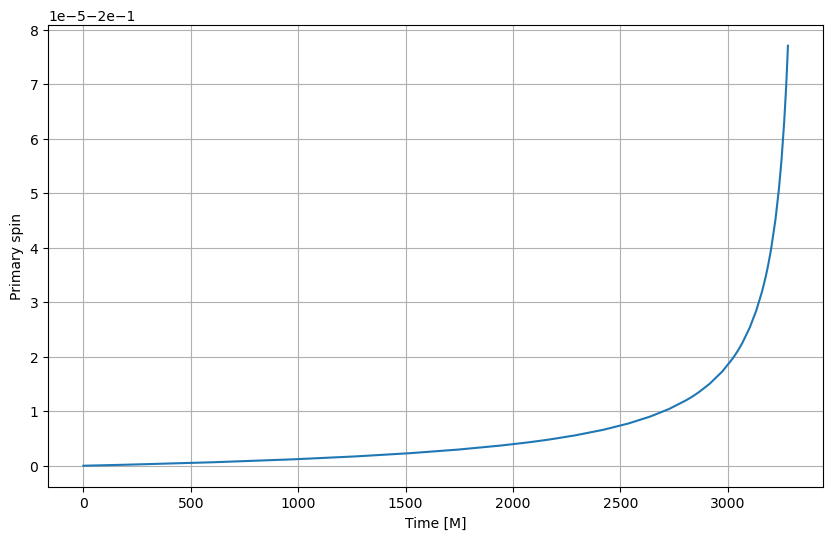

In [11]:
plt.figure(figsize=(10, 6))
plt.plot(t, a + deltachit1)
plt.xlabel("Time [M]")
plt.ylabel("Primary spin")
plt.grid()
plt.show()

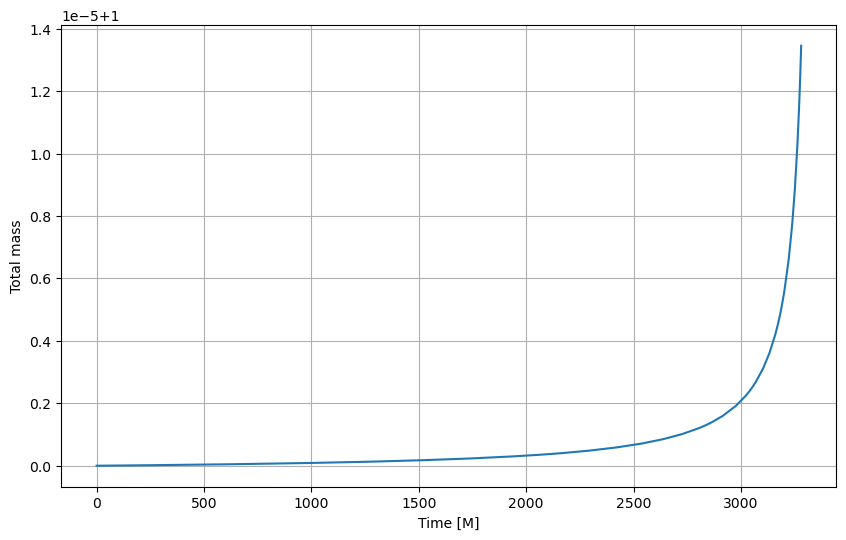

In [12]:
plt.figure(figsize=(10, 6))
plt.plot(t, 1 + deltaM)
plt.xlabel("Time [M]")
plt.ylabel("Total mass")
plt.grid()
plt.show()